In [20]:
# Import Libraries

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading Data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

### import and install seaborn

In [ ]:
# we install it via the terminal
# proceed with import

import seaborn as sns


In [22]:
#only get data analyst jobs in the usa

df_DA_US = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

#Drop NaN values from the column below for accurate visualization

df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

39726      74050.0
139472     84500.0
185237     42500.0
259012    115000.0
761629     72500.0
569682     90000.0
369268    120000.0
389959    112500.0
220245     82500.0
492387    125000.0
Name: salary_year_avg, dtype: float64

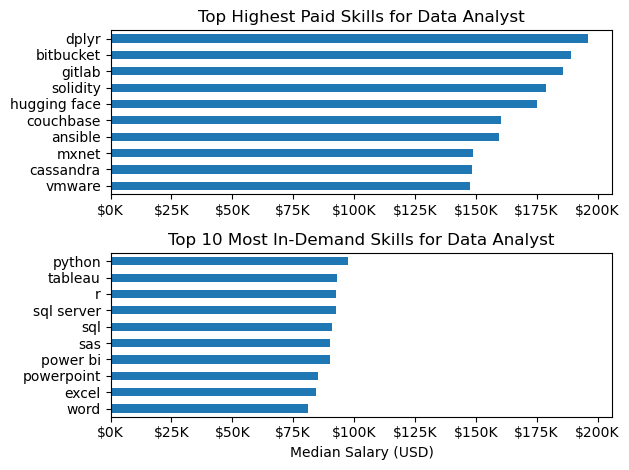

In [23]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US[['job_skills', 'salary_year_avg']]

df_DA_US_group=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

# Top paying skills
df_DA_top_pay=df_DA_US_group.sort_values(by='median', ascending=False).head(10)

# Skills with the highest count
df_DA_skills=df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)

df_DA_skills

#plot

fig, ax =plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()


## using seaborn

In [ ]:
# for custom params never mind

custom_params = {
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (10, 6)
}

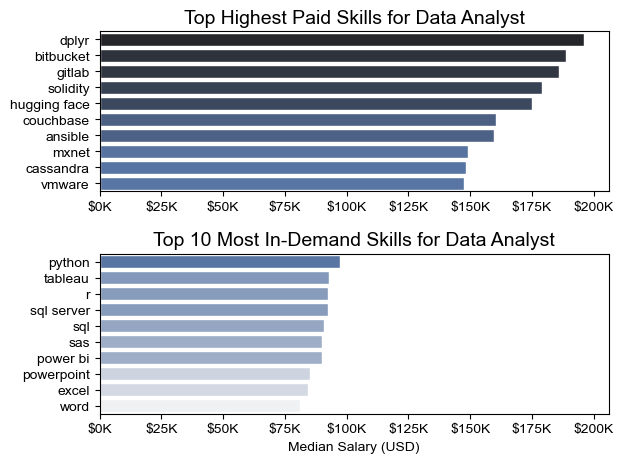

In [30]:
fig, ax =plt.subplots(2,1)
sns.set_theme(style='ticks', rc=custom_params)


# Top Highest Paid Skills for Data Analyst

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()

# df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analyst

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()

# df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()


### Histogram

Text(0, 0.5, 'Number of Jobs')

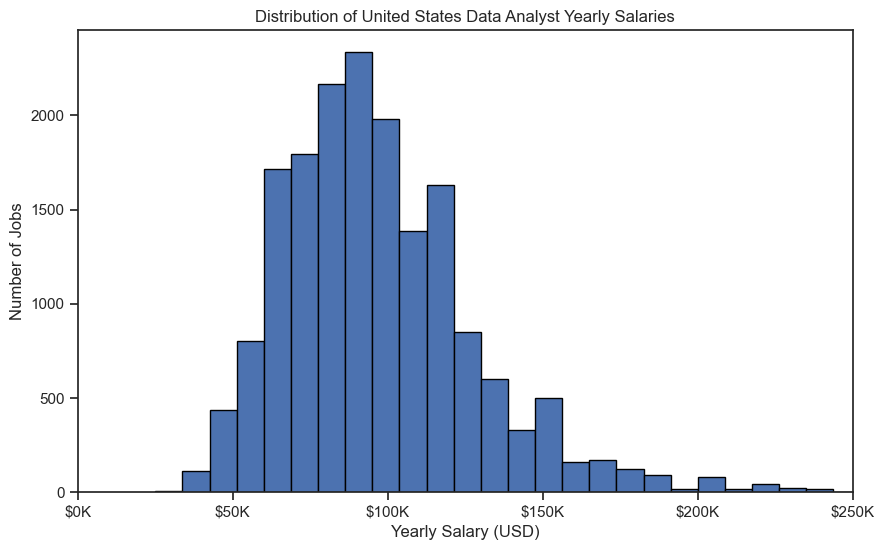

In [37]:
#Lets plot

df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

#Filter the X axis range from 0 to 250000
plt.xlim(0,250000)
# add $ sign to x axis and divide it by 1000
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, 
pos: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')

### Apply seaborn function

Text(12.444444444444445, 0.5, 'Number of Jobs')

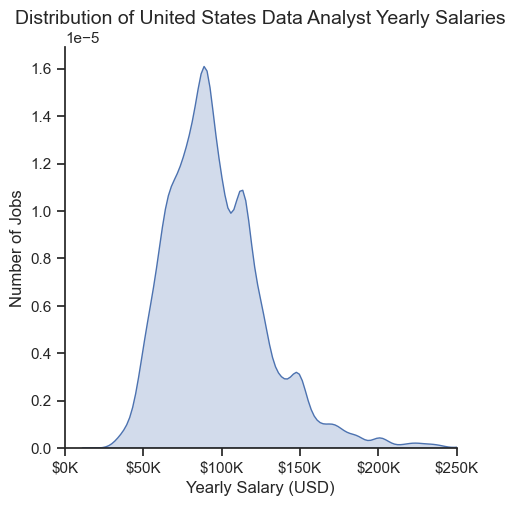

In [38]:
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)

sns.set_theme(style='ticks', rc=custom_params)
plt.xlim(0,250000)
# add $ sign to x axis and divide it by 1000
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, 
pos: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')

### Box Plots

C:\Users\Pc\AppData\Local\Temp\ipykernel_26024\3742444340.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


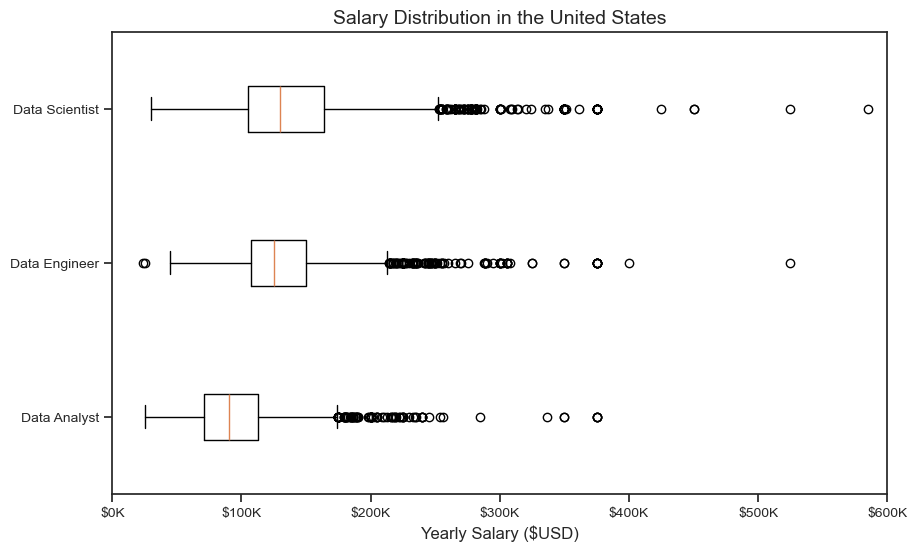

In [39]:
job_titles=['Data Analyst', 'Data Engineer', 'Data Scientist']

#filter the approptiate job_titles
#only get job_titles jobs

df_US = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == 'United States')
].copy()

#drop null values
df_US=df_US.dropna(subset='salary_year_avg')

job_list=[df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

#PLOT
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

# add $ sign to x axis and divide it by 1000
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, 
pos: f'${int(x/1000)}K'))

#Filter the X axis range from 0 to 600000
plt.xlim(0,600000)

plt.show()

### Lets include seaborn

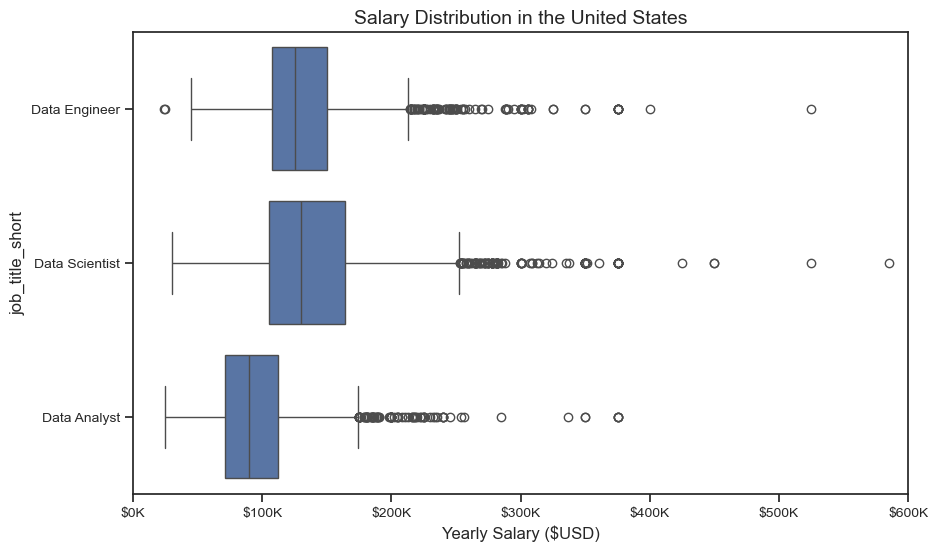

In [41]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

# add $ sign to x axis and divide it by 1000
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, 
pos: f'${int(x/1000)}K'))

#Filter the X axis range from 0 to 600000
plt.xlim(0,600000)

plt.show()